In [5]:
# @title Загружаем датасет
# В Google Colab для скачивания с Kaggle
!pip install kaggle
!mkdir -p ~/.kaggle

# Загрузите свой kaggle.json (нужен аккаунт Kaggle)
from google.colab import files
print('Загрузите kaggle.json')
files.upload()  # Загрузите kaggle.json

!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Скачивание датасета Life Expectancy
!kaggle datasets download -d kumarajarshi/life-expectancy-who


Загрузите kaggle.json


Saving kaggle.json to kaggle (1).json
Dataset URL: https://www.kaggle.com/datasets/kumarajarshi/life-expectancy-who
License(s): other
  0% 0.00/119k [00:00<?, ?B/s]
100% 119k/119k [00:00<00:00, 560MB/s]


In [6]:
# @title Создаем папку data и перемещаем файлы
# Распаковываем датасет Life Expectancy
!unzip life-expectancy-who.zip

# Создаем папку data и перемещаем файлы
!mkdir -p data
!mv "Life Expectancy Data.csv" data/


# Проверяем
!ls -la data/

Archive:  life-expectancy-who.zip
  inflating: Life Expectancy Data.csv  
total 340
drwxr-xr-x 2 root root   4096 Oct  5 15:58  .
drwxr-xr-x 1 root root   4096 Oct  5 15:58  ..
-rw-r--r-- 1 root root 333442 Sep 27  2019 'Life Expectancy Data.csv'


In [7]:
# @title Создаем БД проекта и сырые таблицы raw_... с данными из Life Expectancy Data.csv
# database
import sqlite3
import pandas as pd
import os
import re


def check_data_files():
    """Проверка наличия CSV файлов."""
    print("Проверяем наличие CSV файлов...")

    required_files = [
        'data/Life Expectancy Data.csv'
    ]

    all_files_exist = True
    for file in required_files:
        if os.path.exists(file):
            size = os.path.getsize(file)
            print(f"{file} ({size} байт)")
        else:
            print(f"{file} - ОТСУТСТВУЕТ!")
            all_files_exist = False

    return all_files_exist


def delete_existing_database():
    """Удаление существующей базы данных, если она есть."""
    db_file = 'life_expectancy.db'
    print("Проверяем существующую базу данных...")
    if os.path.exists(db_file):
        os.remove(db_file)
        print("Существующая база данных удалена")
    else:
        print("База данных не существует, создаем новую")


def handle_duplicate_columns(columns):
    """Обрабатывает дублирующиеся названия колонок, добавляя порядковые номера."""
    seen = {}
    result = []

    for col in columns:
        if col not in seen:
            seen[col] = 1
            result.append(col)
        else:
            seen[col] += 1
            new_col = f"{col}_{seen[col]}"
            result.append(new_col)

    return result


def clean_column_name(column_name):
    """Замена запрещенных символов в названиях столбцов."""
    cleaned_name = re.sub(r'[/\\\s\-]+', '_', str(column_name))
    cleaned_name = re.sub(r'_+', '_', cleaned_name)
    cleaned_name = cleaned_name.strip('_')
    return cleaned_name


def truncate_column_name(column_name, max_length=50):
    """Обрезает длинные названия колонок."""
    if len(column_name) > max_length:
        return column_name[:max_length]
    return column_name


def clean_dataframe_columns(df):
    """Очистка названий колонок в DataFrame."""
    cleaned_columns = {}
    original_to_cleaned = {}

    for col in df.columns:
        cleaned_col = clean_column_name(col)
        cleaned_col = truncate_column_name(cleaned_col)
        if cleaned_col != col:
            cleaned_columns[col] = cleaned_col
            original_to_cleaned[col] = cleaned_col
        else:
            original_to_cleaned[col] = col

    if cleaned_columns:
        print("Переименование колонок:")
        for old_name, new_name in cleaned_columns.items():
            print(f"  '{old_name}' -> '{new_name}'")
        df = df.rename(columns=cleaned_columns)

    current_columns = df.columns.tolist()
    unique_columns = handle_duplicate_columns(current_columns)

    if current_columns != unique_columns:
        duplicate_fixes = {}
        for old, new in zip(current_columns, unique_columns):
            if old != new:
                duplicate_fixes[old] = new

        if duplicate_fixes:
            print("Исправление дублирующихся названий колонок:")
            for old_name, new_name in duplicate_fixes.items():
                print(f"  '{old_name}' -> '{new_name}'")
            df = df.rename(columns=duplicate_fixes)

    return df


def print_table_sample(conn, table_name, limit=5):
    """Вывод sample данных из таблицы."""
    print(f"\nСодержимое таблицы {table_name} (первые {limit} записей):")
    print("-" * 80)
    try:
        query = f"SELECT * FROM {table_name} LIMIT {limit}"
        df = pd.read_sql_query(query, conn)
        if len(df) > 0:
            print(df.to_string(index=False))
            count_query = f"SELECT COUNT(*) as total_count FROM {table_name}"
            total_records = pd.read_sql_query(count_query, conn).iloc[0, 0]
            print(f"\nВсего записей в таблице: {total_records}")

            print(f"\nСтруктура таблицы {table_name}:")
            print(f"Кол-во колонок: {len(df.columns)}")
            print("Колонки:")
            for i, col in enumerate(df.columns, 1):
                print(f"  {i}. '{col}'")
        else:
            print("Таблица пуста")
    except Exception as e:
        print(f"Ошибка при чтении таблицы {table_name}: {e}")

    print(f"\nПропущенные значения:")
    missing_values = df.isnull().sum()
    for col, missing_count in missing_values.items():
        if missing_count > 0:
            print(f"  - {col}: {missing_count} пропусков")


def check_column_name_issues(df):
    """Проверяет потенциальные проблемы с названиями колонок."""
    issues_found = False

    duplicate_columns = df.columns[df.columns.duplicated()].tolist()
    if duplicate_columns:
        print("Обнаружены дублирующиеся названия колонок:")
        for col in duplicate_columns:
            print(f"  '{col}'")
        issues_found = True

    return issues_found


def create_life_expectancy_table(csv_file='data/Life Expectancy Data.csv',
                                db_file='life_expectancy.db'):
    """Создание таблицы - копии CSV файла."""
    conn = sqlite3.connect(db_file)

    try:
        print("Загружаем Life Expectancy Data.csv...")

        life_expectancy_df = pd.read_csv(csv_file)

        print("\nПроверка исходных названий колонок...")
        original_issues = check_column_name_issues(life_expectancy_df)

        print("\nОчистка названий колонок...")
        life_expectancy_df = clean_dataframe_columns(life_expectancy_df)

        print("\nПроверка финальных названий колонок...")
        final_issues = check_column_name_issues(life_expectancy_df)

        if not final_issues:
            print("Все проблемы с названиями колонок устранены")

        print("\nСохраняем raw_life_expectancy в базу данных...")
        life_expectancy_df.to_sql(
            'raw_life_expectancy',
            conn,
            if_exists='replace',
            index=False
        )

        print("Таблица raw_life_expectancy создана успешно")

        print_table_sample(conn, 'raw_life_expectancy')

        target_col = 'Life_expectancy'
        if target_col not in life_expectancy_df.columns:
            possible_targets = [
                col for col in life_expectancy_df.columns
                if 'life' in col.lower() or 'expectancy' in col.lower()
            ]
            if possible_targets:
                target_col = possible_targets[0]

        target_stats_query = f"""
        SELECT
            COUNT(*) as total,
            COUNT("{target_col}") as non_null_life_expectancy,
            MIN("{target_col}") as min_life_expectancy,
            MAX("{target_col}") as max_life_expectancy,
            AVG("{target_col}") as avg_life_expectancy
        FROM raw_life_expectancy
        """
        target_stats = pd.read_sql_query(target_stats_query, conn)
        print(f"\nСтатистика по целевой переменной '{target_col}':")
        print(f"Всего записей: {target_stats.iloc[0, 0]}")
        print(f"Непустых значений: {target_stats.iloc[0, 1]}")
        print(f"Минимальная продолжительность: {target_stats.iloc[0, 2]:.2f} лет")
        print(f"Максимальная продолжительность: {target_stats.iloc[0, 3]:.2f} лет")
        print(f"Средняя продолжительность: {target_stats.iloc[0, 4]:.2f} лет")

    except Exception as e:
        print(f"Ошибка при создании сырой таблицы: {e}")
        raise
    finally:
        conn.close()


def verify_database_structure(db_file='life_expectancy.db'):
    """Проверяет структуру базы данных."""
    conn = sqlite3.connect(db_file)

    try:

        cursor = conn.cursor()
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table'")
        tables = cursor.fetchall()

        print("Таблицы в базе данных:")
        for table in tables:
            table_name = table[0]
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            count = cursor.fetchone()[0]
            print(f"  {table_name}: {count} записей")

        return True

    except Exception as e:
        print(f"Ошибка при проверке структуры базы данных: {e}")
        return False
    finally:
        conn.close()


def main_database():
    """Основная функция для создания базы данных."""
    if not check_data_files():
        print("\nПрограмма остановлена: отсутствуют необходимые файлы")
        return False

    try:
        print("\n" + "=" * 60)
        print("ПОДГОТОВКА БАЗЫ ДАННЫХ")
        print("=" * 60)
        delete_existing_database()

        print("\n" + "=" * 60)
        print("СОЗДАНИЕ СЫРОЙ ТАБЛИЦЫ")
        print("=" * 60)
        create_life_expectancy_table()

        print("\n" + "=" * 60)
        print("ПРОВЕРКА СТРУКТУРЫ БАЗЫ ДАННЫХ")
        print("=" * 60)
        verify_database_structure()

        print("\n" + "=" * 60)
        print("БАЗА ДАННЫХ УСПЕШНО СОЗДАНА!")
        print("=" * 60)
        return True

    except Exception as e:
        print(f"\nКРИТИЧЕСКАЯ ОШИБКА: {e}")
        print("Программа остановлена")
        return False


if __name__ == "__main__":
    main_database()

Проверяем наличие CSV файлов...
data/Life Expectancy Data.csv (333442 байт)

ПОДГОТОВКА БАЗЫ ДАННЫХ
Проверяем существующую базу данных...
База данных не существует, создаем новую

СОЗДАНИЕ СЫРОЙ ТАБЛИЦЫ
Загружаем Life Expectancy Data.csv...

Проверка исходных названий колонок...

Очистка названий колонок...
Переименование колонок:
  'Life expectancy ' -> 'Life_expectancy'
  'Adult Mortality' -> 'Adult_Mortality'
  'infant deaths' -> 'infant_deaths'
  'percentage expenditure' -> 'percentage_expenditure'
  'Hepatitis B' -> 'Hepatitis_B'
  'Measles ' -> 'Measles'
  ' BMI ' -> 'BMI'
  'under-five deaths ' -> 'under_five_deaths'
  'Total expenditure' -> 'Total_expenditure'
  'Diphtheria ' -> 'Diphtheria'
  ' HIV/AIDS' -> 'HIV_AIDS'
  ' thinness  1-19 years' -> 'thinness_1_19_years'
  ' thinness 5-9 years' -> 'thinness_5_9_years'
  'Income composition of resources' -> 'Income_composition_of_resources'

Проверка финальных названий колонок...
Все проблемы с названиями колонок устранены

Сохран


3. ВИЗУАЛИЗАЦИЯ ДАННЫХ ДАТАСЕТА
Целевая переменная: Life_expectancy
Всего записей: 2938
Непустых значений целевой переменной: 2928
Статистика целевой переменной:
   Среднее: 69.22 лет
   Стандартное отклонение: 9.52 лет
   Минимальное значение: 36.30 лет
   Максимум: 89.00 лет
   25-й перцентиль: 63.10 лет
   50-й перцентиль: 72.10 лет
   75-й перцентиль: 75.70 лет

Пропущенные значения:
   Life_expectancy: 10 (0.3%)
   Adult_Mortality: 10 (0.3%)
   Alcohol: 194 (6.6%)
   Hepatitis_B: 553 (18.8%)
   BMI: 34 (1.2%)
   Polio: 19 (0.6%)
   Total_expenditure: 226 (7.7%)
   Diphtheria: 19 (0.6%)
   GDP: 448 (15.2%)
   Population: 652 (22.2%)
   thinness_1_19_years: 34 (1.2%)
   thinness_5_9_years: 34 (1.2%)
   Income_composition_of_resources: 167 (5.7%)
   Schooling: 163 (5.5%)


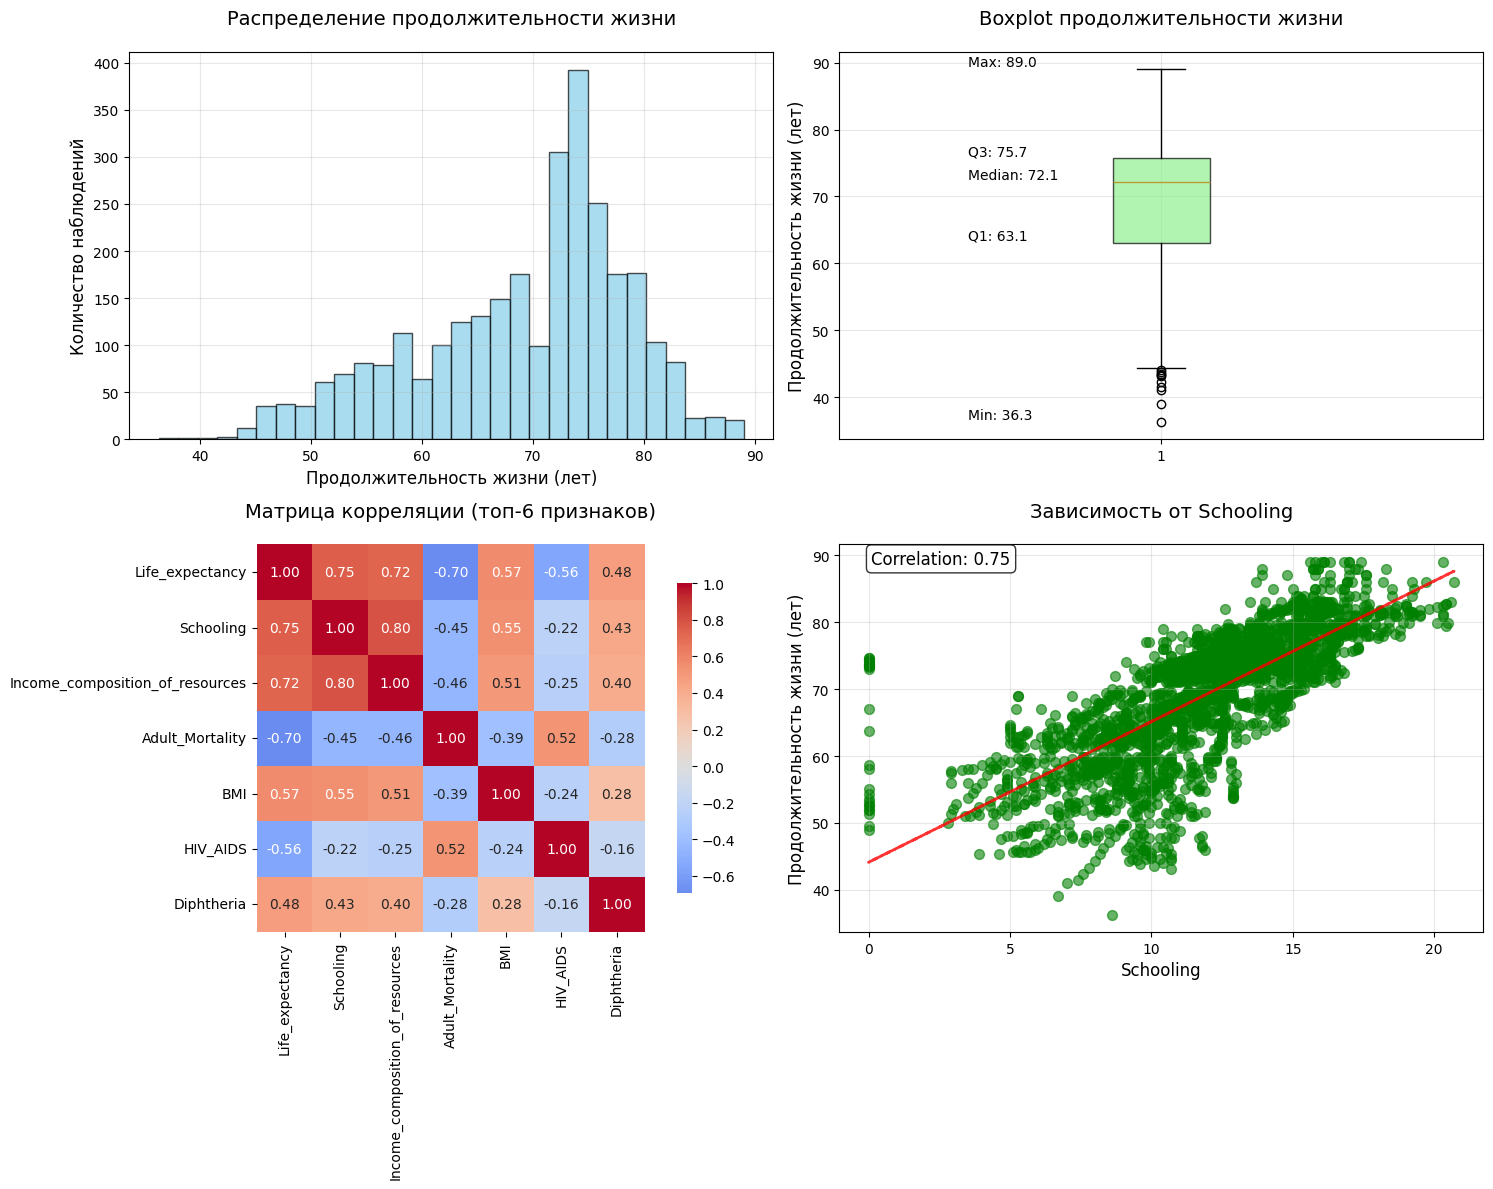


Дополнительная статистика по ключевым признакам:
   Adult_Mortality:
      Среднее: 164.80
      Медиана: 144.00
      Стандартное отклонение: 124.29
   Alcohol:
      Среднее: 4.60
      Медиана: 3.75
      Стандартное отклонение: 4.05
   BMI:
      Среднее: 38.32
      Медиана: 43.50
      Стандартное отклонение: 20.04
   Schooling:
      Среднее: 11.99
      Медиана: 12.30
      Стандартное отклонение: 3.36


In [8]:
# @title Создаем визуализации для анализа данных таблицы raw_life_expectancy
# visualize_data

import os
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns


def visualize_data(db_file='life_expectancy.db'):
    """Визуализация данных для задачи регрессии."""

    if not os.path.exists(db_file):
        print("Ошибка: База данных не найдена")
        return False

    try:
        conn = sqlite3.connect(db_file)
        df = pd.read_sql_query('SELECT * FROM raw_life_expectancy', conn)
        conn.close()

        # Определяем целевую переменную для регрессии
        target_column = 'Life_expectancy'
        if target_column not in df.columns:
            possible_targets = [col for col in df.columns if 'life' in col.lower() or 'expectancy' in col.lower()]
            if possible_targets:
                target_column = possible_targets[0]
            else:
                print("Ошибка: Не найдена целевая переменная продолжительности жизни")
                return False

        print(f"Целевая переменная: {target_column}")
        print(f"Всего записей: {len(df)}")
        print(f"Непустых значений целевой переменной: {df[target_column].notna().sum()}")

        # Анализ целевой переменной
        target_stats = df[target_column].describe()
        print(f"Статистика целевой переменной:")
        print(f"   Среднее: {target_stats['mean']:.2f} лет")
        print(f"   Стандартное отклонение: {target_stats['std']:.2f} лет")
        print(f"   Минимальное значение: {target_stats['min']:.2f} лет")
        print(f"   Максимум: {target_stats['max']:.2f} лет")
        print(f"   25-й перцентиль: {target_stats['25%']:.2f} лет")
        print(f"   50-й перцентиль: {target_stats['50%']:.2f} лет")
        print(f"   75-й перцентиль: {target_stats['75%']:.2f} лет")

        # Анализ пропущенных значений
        nan_counts = df.isnull().sum()
        nan_counts = nan_counts[nan_counts > 0]
        if len(nan_counts) > 0:
            print("\nПропущенные значения:")
            for col, count in nan_counts.items():
                percentage = count / len(df) * 100
                print(f"   {col}: {count} ({percentage:.1f}%)")
        else:
            print("\nПропущенные значения отсутствуют")

        # Создаем копию для визуализации
        df_viz = df.copy()

        # Создаем фигуру с 2 графиками в строке
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))

        # График 1: Распределение целевой переменной
        axes[0, 0].hist(df_viz[target_column].dropna(), bins=30, alpha=0.7,
                       color='skyblue', edgecolor='black')
        axes[0, 0].set_title('Распределение продолжительности жизни', fontsize=14, pad=20)
        axes[0, 0].set_xlabel('Продолжительность жизни (лет)', fontsize=12)
        axes[0, 0].set_ylabel('Количество наблюдений', fontsize=12)
        axes[0, 0].grid(True, alpha=0.3)

        # График 2: Boxplot целевой переменной
        boxplot_data = df_viz[target_column].dropna()
        axes[0, 1].boxplot(boxplot_data, vert=True, patch_artist=True,
                          boxprops=dict(facecolor='lightgreen', alpha=0.7))
        axes[0, 1].set_title('Boxplot продолжительности жизни', fontsize=14, pad=20)
        axes[0, 1].set_ylabel('Продолжительность жизни (лет)', fontsize=12)
        axes[0, 1].grid(True, alpha=0.3)

        # Добавляем статистику к boxplot
        axes[0, 1].text(0.7, target_stats['min'], f'Min: {target_stats["min"]:.1f}',
                       fontsize=10, va='bottom')
        axes[0, 1].text(0.7, target_stats['25%'], f'Q1: {target_stats["25%"]:.1f}',
                       fontsize=10, va='bottom')
        axes[0, 1].text(0.7, target_stats['50%'], f'Median: {target_stats["50%"]:.1f}',
                       fontsize=10, va='bottom')
        axes[0, 1].text(0.7, target_stats['75%'], f'Q3: {target_stats["75%"]:.1f}',
                       fontsize=10, va='bottom')
        axes[0, 1].text(0.7, target_stats['max'], f'Max: {target_stats["max"]:.1f}',
                       fontsize=10, va='bottom')

        # График 3: Матрица корреляции
        numeric_cols = df_viz.select_dtypes(include=[np.number]).columns.tolist()

        if target_column in numeric_cols and len(numeric_cols) > 1:
            correlations = df_viz[numeric_cols].corr()[target_column].abs().sort_values(ascending=False)
            top_features = correlations.index[1:7].tolist()
            selected_cols = [target_column] + top_features

            correlation_matrix = df_viz[selected_cols].corr()

            # Строим heatmap со всеми значениями корреляции
            sns.heatmap(
                correlation_matrix,
                annot=True,
                cmap='coolwarm',
                center=0,
                fmt='.2f',
                square=True,
                ax=axes[1, 0],
                annot_kws={'size': 10},
                cbar_kws={'shrink': 0.8}
            )
            axes[1, 0].set_title('Матрица корреляции (топ-6 признаков)', fontsize=14, pad=20)
            axes[1, 0].tick_params(axis='x', labelsize=10, rotation=90)
            axes[1, 0].tick_params(axis='y', labelsize=10, rotation=0)

        # График 4: Зависимость от наиболее коррелирующего признака
        if target_column in numeric_cols and len(numeric_cols) > 1:
            correlations = df_viz[numeric_cols].corr()[target_column].abs().sort_values(ascending=False)
            if len(correlations) > 1:
                top_corr_feature = correlations.index[1]

                valid_data = df_viz[[top_corr_feature, target_column]].dropna()

                if len(valid_data) > 1:
                    axes[1, 1].scatter(valid_data[top_corr_feature], valid_data[target_column],
                                     alpha=0.6, color='green', s=50)

                    # Линия тренда
                    z = np.polyfit(valid_data[top_corr_feature], valid_data[target_column], 1)
                    p = np.poly1d(z)
                    axes[1, 1].plot(valid_data[top_corr_feature], p(valid_data[top_corr_feature]),
                                  "r--", alpha=0.8, linewidth=2)

                    correlation = valid_data[top_corr_feature].corr(valid_data[target_column])
                    axes[1, 1].text(0.05, 0.95, f'Correlation: {correlation:.2f}',
                                  transform=axes[1, 1].transAxes, fontsize=12,
                                  bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

                    axes[1, 1].set_title(f'Зависимость от {top_corr_feature}', fontsize=14, pad=20)
                    axes[1, 1].set_xlabel(top_corr_feature, fontsize=12)
                    axes[1, 1].set_ylabel('Продолжительность жизни (лет)', fontsize=12)
                    axes[1, 1].grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

        # Дополнительная статистика
        print("\nДополнительная статистика по ключевым признакам:")
        key_features = ['Adult_Mortality', 'Alcohol', 'BMI', 'Schooling']
        available_features = [f for f in key_features if f in df_viz.columns]

        for feature in available_features:
            if df_viz[feature].dtype in [np.int64, np.float64]:
                stats = df_viz[feature].describe()
                print(f"   {feature}:")
                print(f"      Среднее: {stats['mean']:.2f}")
                print(f"      Медиана: {stats['50%']:.2f}")
                print(f"      Стандартное отклонение: {stats['std']:.2f}")

        return True

    except Exception as e:
        print(f"Ошибка при визуализации данных: {e}")
        return False


if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("3. ВИЗУАЛИЗАЦИЯ ДАННЫХ ДАТАСЕТА")
    print("=" * 60)
    visualize_data()

In [9]:
# @title Проводим предобработку данных для регрессии
# data_processing

import os
import pandas as pd
import numpy as np
import sqlite3
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer

def print_table_sample(conn, table_name, limit=3):
    """Вывод sample данных из таблицы."""
    print(f"\nСодержимое таблицы {table_name} (первые {limit} записей):")
    print("-" * 60)
    try:
        query = f"SELECT * FROM {table_name} LIMIT {limit}"
        df = pd.read_sql_query(query, conn)
        if len(df) > 0:
            print(df.to_string(index=False))
            count_query = f"SELECT COUNT(*) as total_count FROM {table_name}"
            total_records = pd.read_sql_query(count_query, conn).iloc[0, 0]
            print(f"Всего записей в таблице: {total_records}")
    except Exception as e:
        print(f"Ошибка при чтении таблицы {table_name}: {e}")


def print_database_structure(db_file='life_expectancy.db'):
    """Вывод структуры базы данных и примеров данных."""
    if not os.path.exists(db_file):
        print("База данных не найдена")
        return

    conn = sqlite3.connect(db_file)
    cursor = conn.cursor()

    try:
        cursor.execute("SELECT name FROM sqlite_master WHERE type='table' ORDER BY name;")
        tables = cursor.fetchall()

        print("Таблицы в базе данных:")
        for table in tables:
            table_name = table[0]
            cursor.execute(f"SELECT COUNT(*) FROM {table_name}")
            count = cursor.fetchone()[0]
            print(f"   {table_name}: {count} записей")

        print_table_sample(conn, 'raw_life_expectancy')
        print_table_sample(conn, 'life_expectancy_processed')

    except Exception as e:
        print(f"Ошибка при выводе структуры: {e}")
    finally:
        conn.close()


def ensure_numeric_data(df, target_col):
    """Гарантирует, что все признаки являются числовыми."""
    df_clean = df.copy()

    for col in df_clean.columns:
        if col == target_col:
            continue
        if df_clean[col].dtype == 'object':
            encoder = LabelEncoder()
            df_clean[col] = encoder.fit_transform(df_clean[col].astype(str))

    return df_clean


def preprocess_data(db_file='life_expectancy.db'):
    """Предобработка данных для задачи регрессии."""
    print("Предобработка данных для регрессии...")

    if not os.path.exists(db_file):
        print("Ошибка: База данных не найдена")
        return False

    try:
        conn = sqlite3.connect(db_file)
        df = pd.read_sql_query('SELECT * FROM raw_life_expectancy', conn)

        df_processed = df.copy()

        target_col = 'Life_expectancy'
        if target_col not in df_processed.columns:
            possible_targets = [
                col for col in df_processed.columns
                if 'life' in col.lower() or 'expectancy' in col.lower()
            ]
            if possible_targets:
                target_col = possible_targets[0]
            else:
                print("Ошибка: Не найдена целевая переменная")
                return False

        print("\n1. Обработка целевой переменной")
        print("-" * 40)

        target_nan_count = df_processed[target_col].isnull().sum()
        if target_nan_count > 0:
            print(f"Удаляем {target_nan_count} строк с пропусками в целевой переменной")
            df_processed = df_processed.dropna(subset=[target_col])

        numerical_cols = df_processed.select_dtypes(include=[np.number]).columns.tolist()
        if target_col in numerical_cols:
            numerical_cols.remove(target_col)

        categorical_cols = df_processed.select_dtypes(include=['object']).columns.tolist()

        print(f"Числовые колонки: {len(numerical_cols)}")
        print(f"Категориальные колонки: {len(categorical_cols)}")



        print("\n2. Обработка пропущенных значений")
        print("-" * 40)

        if numerical_cols:
            numerical_imputer = SimpleImputer(strategy='median')
            df_processed[numerical_cols] = numerical_imputer.fit_transform(df_processed[numerical_cols])

        if categorical_cols:
            categorical_imputer = SimpleImputer(strategy='most_frequent')
            df_processed[categorical_cols] = categorical_imputer.fit_transform(df_processed[categorical_cols])

        print("\n3. Кодирование категориальных признаков")
        print("-" * 40)

        encoders = {}
        for col in categorical_cols:
            encoder = LabelEncoder()
            df_processed[col] = encoder.fit_transform(df_processed[col].astype(str))
            encoders[col] = encoder
            print(f"Закодирован: {col}")

        print("\n4. Гарантия числовых данных")
        print("-" * 40)

        df_processed = ensure_numeric_data(df_processed, target_col)

        print("\n5. Масштабирование числовых признаков")
        print("-" * 40)

        cols_to_scale = [
            col for col in df_processed.columns
            if col != target_col and df_processed[col].dtype in [np.int64, np.float64]
        ]

        if cols_to_scale:
            scaler = StandardScaler()
            df_processed[cols_to_scale] = scaler.fit_transform(df_processed[cols_to_scale])
            print(f"Масштабировано признаков: {len(cols_to_scale)}")

        print("\n6. Сохранение результатов")
        print("-" * 40)

        df_processed.to_sql('life_expectancy_processed', conn, if_exists='replace', index=False)
        print("Обработанные данные сохранены в базу")

        X = df_processed.drop(target_col, axis=1)
        y = df_processed[target_col]

        print(f"\nФинальная статистика:")
        print(f"Признаки (X): {X.shape}")
        print(f"Целевая переменная (y): {y.shape}")

        artifacts = {
            'numerical_imputer': numerical_imputer if numerical_cols else None,
            'categorical_imputer': categorical_imputer if categorical_cols else None,
            'encoders': encoders,
            'scaler': scaler if cols_to_scale else None,
            'feature_names': X.columns.tolist(),
            'target_name': target_col
        }
        joblib.dump(artifacts, 'preprocessing_artifacts.pkl')
        print("Артефакты предобработки сохранены")

        print_database_structure(db_file)

        conn.close()
        return True

    except Exception as e:
        print(f"Ошибка при предобработке данных: {e}")
        import traceback
        traceback.print_exc()
        return False


if __name__ == "__main__":
    print("\n" + "=" * 60)
    print("ПРЕДОБРАБОТКА ДАННЫХ ДЛЯ РЕГРЕССИИ")
    print("=" * 60)
    success = preprocess_data()

    if success:
        print("\nПРЕДОБРАБОТКА УСПЕШНО ЗАВЕРШЕНА")
    else:
        print("\nПРЕДОБРАБОТКА ЗАВЕРШИЛАСЬ С ОШИБКАМИ")


ПРЕДОБРАБОТКА ДАННЫХ ДЛЯ РЕГРЕССИИ
Предобработка данных для регрессии...

1. Обработка целевой переменной
----------------------------------------
Удаляем 10 строк с пропусками в целевой переменной
Числовые колонки: 19
Категориальные колонки: 2

2. Обработка пропущенных значений
----------------------------------------

3. Кодирование категориальных признаков
----------------------------------------
Закодирован: Country
Закодирован: Status

4. Гарантия числовых данных
----------------------------------------

5. Масштабирование числовых признаков
----------------------------------------
Масштабировано признаков: 21

6. Сохранение результатов
----------------------------------------
Обработанные данные сохранены в базу

Финальная статистика:
Признаки (X): (2928, 21)
Целевая переменная (y): (2928,)
Артефакты предобработки сохранены
Таблицы в базе данных:
   life_expectancy_processed: 2928 записей
   raw_life_expectancy: 2938 записей

Содержимое таблицы raw_life_expectancy (первые 3 запи

In [12]:
# @title Визуализация результатов регрессии
%%writefile regression_visualization.py

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


def plot_predictions(y_true, y_pred, num_points=20):
    """Визуализация истинных и предсказанных значений."""
    plt.figure(figsize=(12, 6))
    plt.scatter(range(num_points), y_true[:num_points], color='blue',
                label='Истинные значения', alpha=0.7)
    plt.scatter(range(num_points), y_pred[:num_points], color='red',
                label='Предсказанные значения', alpha=0.7)
    plt.xlabel('Индекс наблюдения')
    plt.ylabel('Продолжительность жизни')
    plt.title('Истинные и предсказанные значения')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


def plot_regression_results(y_true, y_pred, model=None, feature_names=None):
    """
    Визуализация результатов регрессионной модели.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    plt.style.use('default')
    sns.set_palette("husl")

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    fig.suptitle('Визуализация результатов регрессии',
                 fontsize=16, fontweight='bold')

    # 1. Фактические vs Предсказанные значения
    axes[0].scatter(y_true, y_pred, alpha=0.6, color='blue', s=50)
    axes[0].plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()],
                 'r--', lw=2, label='Идеальная линия')
    axes[0].set_xlabel('Фактические значения (лет)')
    axes[0].set_ylabel('Предсказанные значения (лет)')
    axes[0].set_title('Фактические vs Предсказанные значения')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    r2 = r2_score(y_true, y_pred)
    axes[0].text(0.05, 0.95, f'R2 = {r2:.3f}',
                 transform=axes[0].transAxes, fontsize=12,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    # 2. Распределение ошибок
    errors = y_pred - y_true
    axes[1].hist(errors, bins=30, alpha=0.7, color='orange', edgecolor='black')
    axes[1].axvline(x=0, color='red', linestyle='--', label='Нет ошибки')
    axes[1].set_xlabel('Ошибка предсказания (лет)')
    axes[1].set_ylabel('Частота')
    axes[1].set_title('Распределение ошибок предсказания')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    mean_error = errors.mean()
    std_error = errors.std()
    axes[1].text(0.05, 0.95, f'Среднее: {mean_error:.2f}\nСтд: {std_error:.2f}',
                 transform=axes[1].transAxes, fontsize=10,
                 bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))

    plt.tight_layout()
    plt.show()

    print_metrics(y_true, y_pred)


def print_metrics(y_true, y_pred):
    """Вывод метрик регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print("МЕТРИКИ РЕГРЕССИИ:")
    print("=" * 40)
    print(f"Mean Squared Error (MSE): {mse:.2f}")
    print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
    print(f"Mean Absolute Error (MAE): {mae:.2f}")
    print(f"R2 Score: {r2:.4f}")

    errors = y_pred - y_true
    print("\nСТАТИСТИКА ОШИБОК:")
    print(f"Средняя ошибка: {errors.mean():.2f} лет")
    print(f"Стандартное отклонение ошибок: {errors.std():.2f} лет")
    print(f"Медианная ошибка: {np.median(errors):.2f} лет")
    print(f"Максимальная ошибка: {errors.max():.2f} лет")
    print(f"Минимальная ошибка: {errors.min():.2f} лет")


def plot_prediction_comparison(y_true, y_pred, num_points=25):
    """Сравнение реальных и предсказанных значений."""
    try:
        y_true_series = pd.Series(y_true).reset_index(drop=True)
        y_pred_series = pd.Series(y_pred).reset_index(drop=True)

        if len(y_true_series) != len(y_pred_series):
            print(f"Предупреждение: разная длина y_true ({len(y_true_series)}) и y_pred ({len(y_pred_series)})")
            min_length = min(len(y_true_series), len(y_pred_series))
            y_true_series = y_true_series.iloc[:min_length]
            y_pred_series = y_pred_series.iloc[:min_length]

        num_points = min(num_points, len(y_true_series))

        indices = list(range(num_points))

        plt.figure(figsize=(14, 6))

        x_pos = np.arange(num_points)
        width = 0.35

        true_values = y_true_series.iloc[indices].values
        pred_values = y_pred_series.iloc[indices].values

        plt.bar(x_pos - width/2, true_values, width,
                label='Реальные значения', alpha=0.7, color='blue')
        plt.bar(x_pos + width/2, pred_values, width,
                label='Предсказания', alpha=0.7, color='red')

        plt.xlabel('Номер наблюдения')
        plt.ylabel('Продолжительность жизни')
        plt.title('Сравнение реальных и предсказанных значений')
        plt.legend()
        plt.xticks(x_pos, [f'#{i+1}' for i in indices])
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

        print(f"Показано первых {num_points} наблюдений из {len(y_true_series)}")

    except Exception as e:
        print(f"Ошибка в plot_prediction_comparison: {e}")
        raise


def plot_residual_analysis(y_true, y_pred):
    """Детальный анализ остатков."""
    residuals = y_pred - y_true

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle('Детальный анализ остатков предсказания', fontsize=16)

    # 1. Распределение остатков
    axes[0, 0].hist(residuals, bins=30, alpha=0.7, color='purple',
                    edgecolor='black', density=True)
    axes[0, 0].set_xlabel('Остатки (лет)')
    axes[0, 0].set_ylabel('Плотность вероятности')
    axes[0, 0].set_title('Распределение остатков')
    axes[0, 0].grid(True, alpha=0.3)

    # 2. Q-Q plot
    from scipy import stats
    stats.probplot(residuals, dist="norm", plot=axes[0, 1])
    axes[0, 1].set_title('Q-Q график остатков')
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Остатки vs Предсказанные значения
    axes[1, 0].scatter(y_pred, residuals, alpha=0.6, color='green', s=50)
    axes[1, 0].axhline(y=0, color='red', linestyle='--', linewidth=2)
    axes[1, 0].set_xlabel('Предсказанные значения (лет)')
    axes[1, 0].set_ylabel('Остатки (лет)')
    axes[1, 0].set_title('Остатки vs Предсказанные значения')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Автокорреляция остатков
    axes[1, 1].acorr(residuals, maxlags=20, color='teal')
    axes[1, 1].axhline(y=0, color='red', linestyle='-', alpha=0.3)
    axes[1, 1].set_xlabel('Лаг')
    axes[1, 1].set_ylabel('Автокорреляция')
    axes[1, 1].set_title('Автокорреляция остатков')
    axes[1, 1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

Writing regression_visualization.py


ПРЕДСКАЗАНИЕ ПРОДОЛЖИТЕЛЬНОСТИ ЖИЗНИ С ПОМОЩЬЮ RANDOM FOREST
Целевая переменная: Life_expectancy
Размерность данных: (2928, 21)
Обучающая выборка: (2049, 21)
Тестовая выборка: (879, 21)
Обучение модели Random Forest...

МЕТРИКИ КАЧЕСТВА МОДЕЛИ
Метрики на обучающей выборке:
  MSE: 0.55
  RMSE: 0.74
  MAE: 0.47
  R2: 0.9939
Метрики на тестовой выборке:
  MSE: 3.61
  RMSE: 1.90
  MAE: 1.19
  R2: 0.9613
Топ-15 самых важных признаков:
                        feature  importance
                       HIV_AIDS    0.593208
Income_composition_of_resources    0.174040
                Adult_Mortality    0.118932
              under_five_deaths    0.017933
                            BMI    0.016926
                      Schooling    0.010599
             thinness_5_9_years    0.009939
                           Year    0.008089
                        Alcohol    0.007556
            thinness_1_19_years    0.005392
              Total_expenditure    0.004824
                        Country    0.0

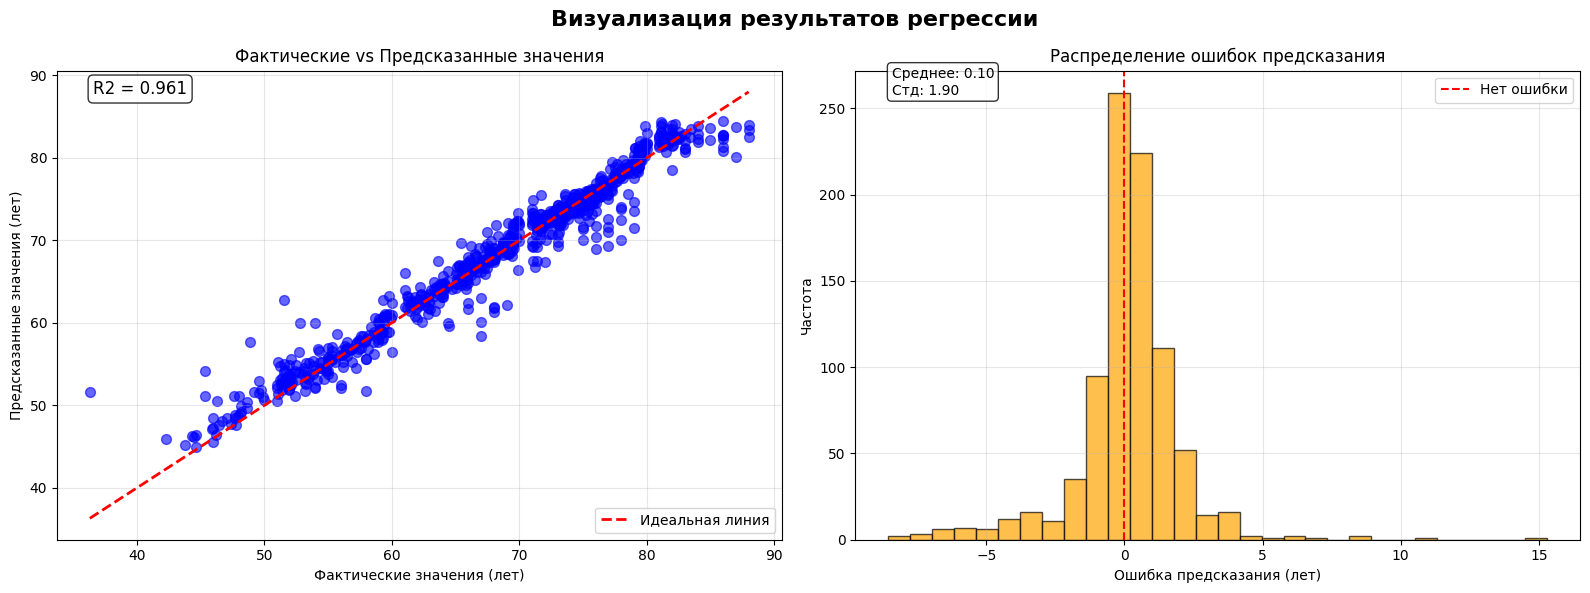

МЕТРИКИ РЕГРЕССИИ:
Mean Squared Error (MSE): 3.61
Root Mean Squared Error (RMSE): 1.90
Mean Absolute Error (MAE): 1.19
R2 Score: 0.9613

СТАТИСТИКА ОШИБОК:
Средняя ошибка: 0.10 лет
Стандартное отклонение ошибок: 1.90 лет
Медианная ошибка: 0.17 лет
Максимальная ошибка: 15.30 лет
Минимальная ошибка: -8.55 лет

СРАВНЕНИЕ ПЕРВЫХ 50 ЗНАЧЕНИЙ:


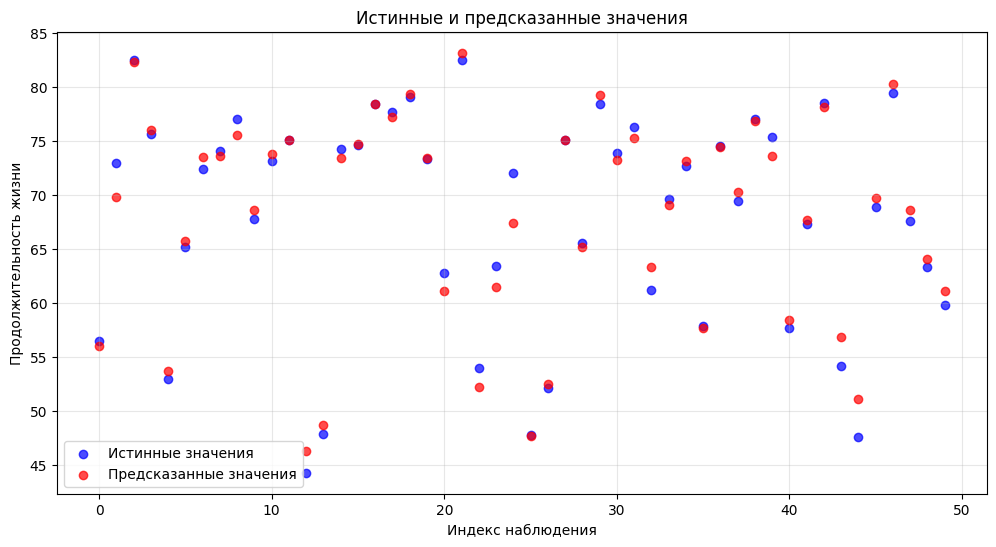

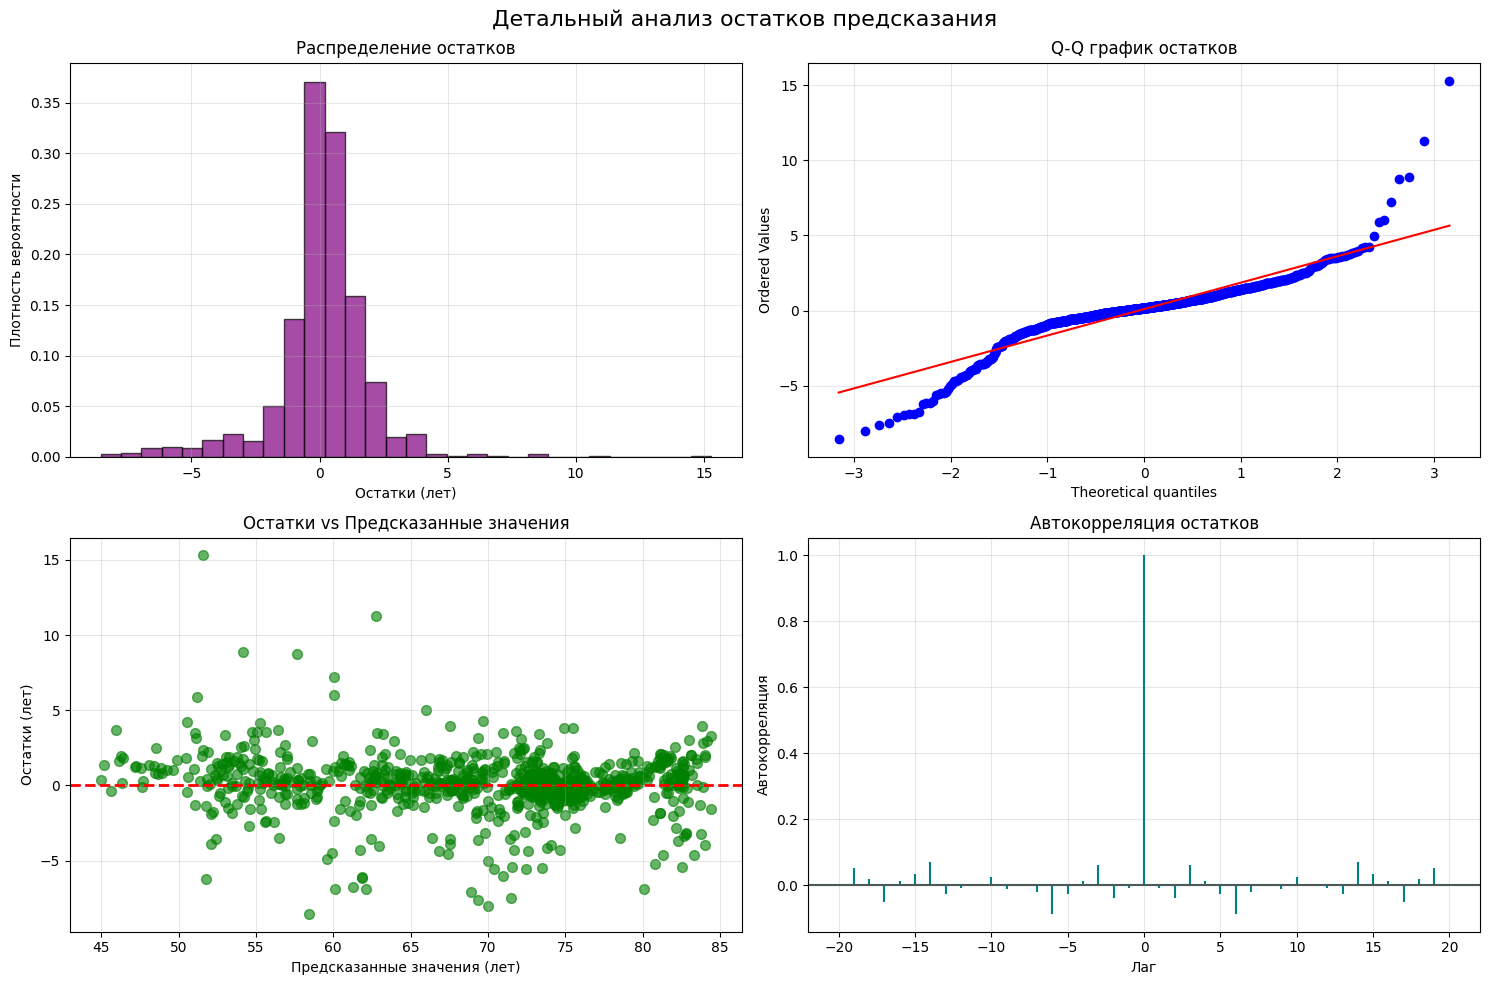

In [1]:
# @title RandomForestRegressor для предсказания продолжительности жизни
# random_forest_regression

import os
import pandas as pd
import numpy as np
import sqlite3
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import regression_visualization as rv


def load_processed_data(db_file='life_expectancy.db'):
    """Загрузка обработанных данных из БД."""
    try:
        conn = sqlite3.connect(db_file)
        df = pd.read_sql_query('SELECT * FROM life_expectancy_processed', conn)
        conn.close()

        target_col = 'Life_expectancy'
        if target_col not in df.columns:
            possible_targets = [col for col in df.columns
                              if 'life' in col.lower() or 'expectancy' in col.lower()]
            if possible_targets:
                target_col = possible_targets[0]
            else:
                print("Ошибка: Не найдена целевая переменная")
                return None, None, None

        # Проверяем и преобразуем нечисловые колонки
        for col in df.columns:
            if col != target_col and df[col].dtype == 'object':
                from sklearn.preprocessing import LabelEncoder
                encoder = LabelEncoder()
                df[col] = encoder.fit_transform(df[col].astype(str))

        X = df.drop(target_col, axis=1)
        y = df[target_col]

        return X, y, target_col

    except Exception as e:
        print(f"Ошибка при загрузке данных: {e}")
        return None, None, None


def calculate_regression_metrics(y_true, y_pred, dataset_name):
    """Вычисление метрик регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)  # Исправление: вычисляем RMSE через sqrt(MSE)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Метрики на {dataset_name} выборке:")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R2: {r2:.4f}")

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


def train_random_forest(X, y, test_size=0.3, random_state=42):
    """Обучение модели Random Forest."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print(f"Обучающая выборка: {X_train.shape}")
    print(f"Тестовая выборка: {X_test.shape}")

    rf_regressor = RandomForestRegressor(
        # n_estimators=100,
        # max_depth=15,
        # min_samples_split=5,
        # min_samples_leaf=2,
        # max_features='sqrt',
        # random_state=random_state,
        # n_jobs=-1
        n_estimators=100,
        max_depth=15,
        random_state=42,
        n_jobs=-1
    )

    print("Обучение модели Random Forest...")
    rf_regressor.fit(X_train, y_train)

    y_pred_train = rf_regressor.predict(X_train)
    y_pred_test = rf_regressor.predict(X_test)

    return {
        'model': rf_regressor,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test
    }


def analyze_feature_importance(model, feature_names, top_n=15):
    """Анализ важности признаков."""
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"Топ-{top_n} самых важных признаков:")
    print(feature_importance.head(top_n).to_string(index=False))

    return feature_importance


def main():
    """Основная функция программы."""
    print("ПРЕДСКАЗАНИЕ ПРОДОЛЖИТЕЛЬНОСТИ ЖИЗНИ С ПОМОЩЬЮ RANDOM FOREST")
    print("=" * 65)

    try:
        X, y, target_col = load_processed_data()

        if X is None or y is None:
            print("Не удалось загрузить данные")
            return

        print(f"Целевая переменная: {target_col}")
        print(f"Размерность данных: {X.shape}")

        results = train_random_forest(X, y)

        print("\nМЕТРИКИ КАЧЕСТВА МОДЕЛИ")
        print("=" * 50)

        train_metrics = calculate_regression_metrics(
            results['y_train'], results['y_pred_train'], "обучающей"
        )
        test_metrics = calculate_regression_metrics(
            results['y_test'], results['y_pred_test'], "тестовой"
        )

        feature_importance = analyze_feature_importance(
            results['model'], X.columns.tolist()
        )

        print("\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
        print("=" * 50)

        rv.plot_regression_results(
            results['y_test'],
            results['y_pred_test'],
            model=results['model'],
            feature_names=X.columns.tolist()
        )

        # Дополнительные визуализации
        print("\nСРАВНЕНИЕ ПЕРВЫХ 50 ЗНАЧЕНИЙ:")
        rv.plot_predictions(results['y_test'], results['y_pred_test'], num_points=50)
        rv.plot_residual_analysis(results['y_test'], results['y_pred_test'])


        # joblib.dump(results['model'], 'random_forest_model.pkl')
        # print("Модель сохранена в random_forest_model.pkl")

        return {
            'model': results['model'],
            'X_train': results['X_train'],
            'X_test': results['X_test'],
            'y_train': results['y_train'],
            'y_test': results['y_test'],
            'y_pred_train': results['y_pred_train'],
            'y_pred_test': results['y_pred_test'],
            'train_metrics': train_metrics,
            'test_metrics': test_metrics,
            'feature_importance': feature_importance
        }

    except Exception as e:
        print(f"Критическая ошибка: {e}")
        import traceback
        traceback.print_exc()
        return None


if __name__ == "__main__":
    results = main()

ПРЕДСКАЗАНИЕ ПРОДОЛЖИТЕЛЬНОСТИ ЖИЗНИ С ПОМОЩЬЮ GRADIENT BOOSTING
Целевая переменная: Life_expectancy
Размерность данных: (2928, 21)
Обучающая выборка: (2049, 21)
Тестовая выборка: (879, 21)
Обучение модели Gradient Boosting...

МЕТРИКИ КАЧЕСТВА МОДЕЛИ
Метрики на обучающей выборке:
  MSE: 0.84
  RMSE: 0.92
  MAE: 0.63
  R2: 0.9906
Метрики на тестовой выборке:
  MSE: 3.49
  RMSE: 1.87
  MAE: 1.22
  R2: 0.9626
Топ-15 самых важных признаков:
                        feature  importance
                       HIV_AIDS    0.538188
Income_composition_of_resources    0.183077
                Adult_Mortality    0.155229
              under_five_deaths    0.022931
             thinness_5_9_years    0.016058
                      Schooling    0.012727
                            BMI    0.012702
                        Alcohol    0.008841
                           Year    0.007201
                        Country    0.005925
                     Diphtheria    0.005442
            thinness_1_19_year

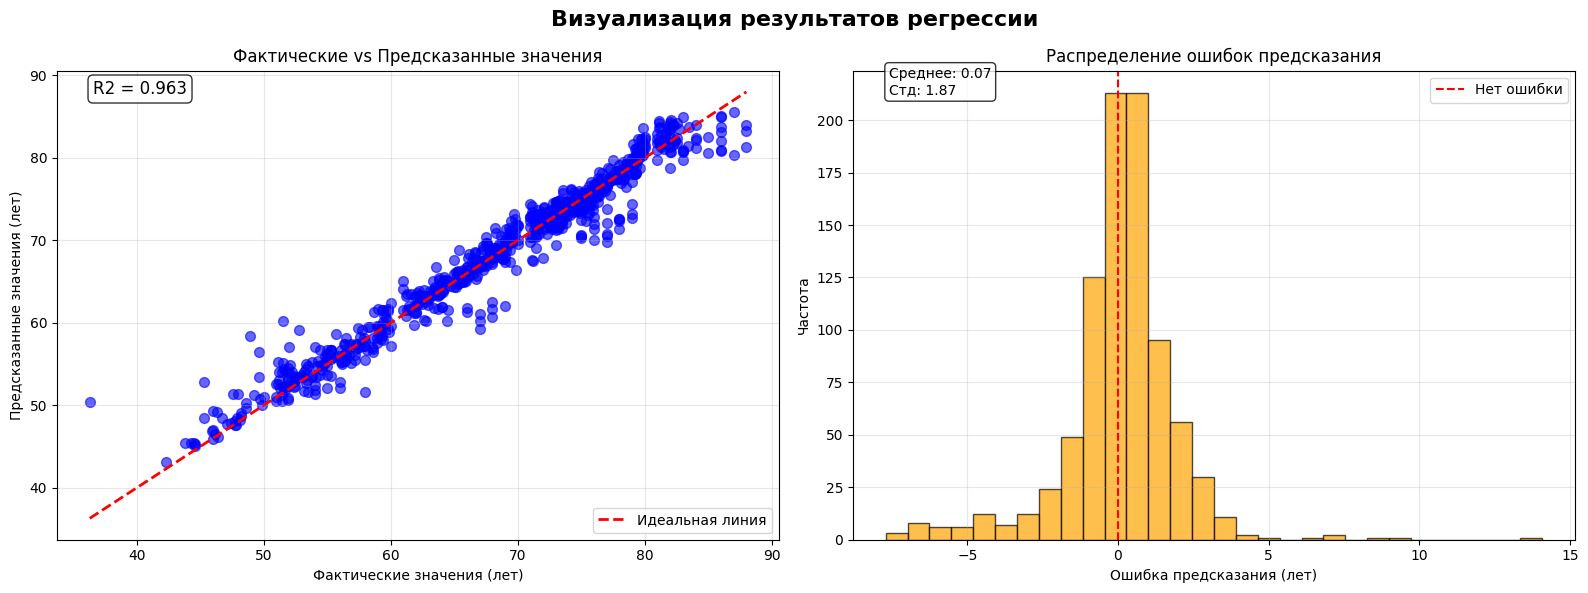

МЕТРИКИ РЕГРЕССИИ:
Mean Squared Error (MSE): 3.49
Root Mean Squared Error (RMSE): 1.87
Mean Absolute Error (MAE): 1.22
R2 Score: 0.9626

СТАТИСТИКА ОШИБОК:
Средняя ошибка: 0.07 лет
Стандартное отклонение ошибок: 1.87 лет
Медианная ошибка: 0.20 лет
Максимальная ошибка: 14.08 лет
Минимальная ошибка: -7.71 лет

СРАВНЕНИЕ ПЕРВЫХ 50 ЗНАЧЕНИЙ:


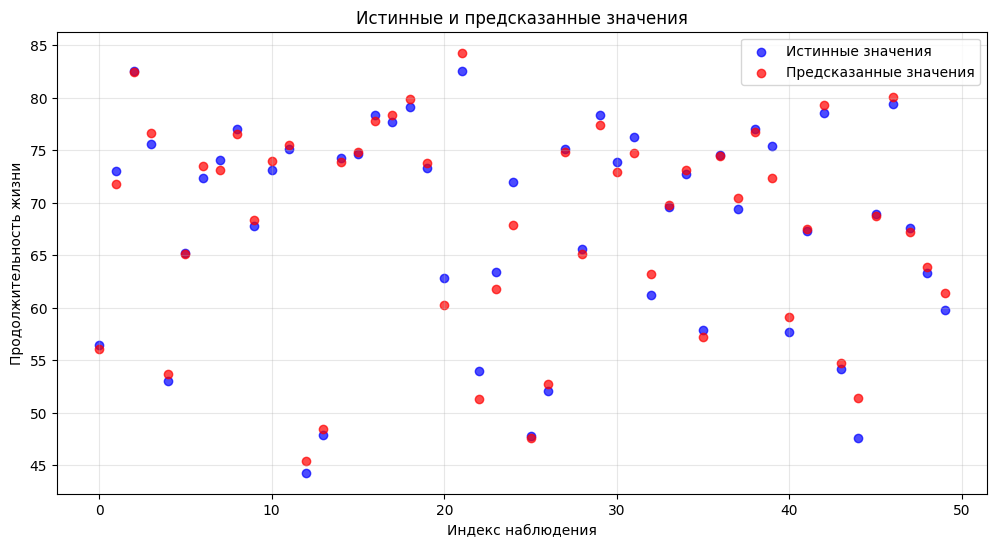

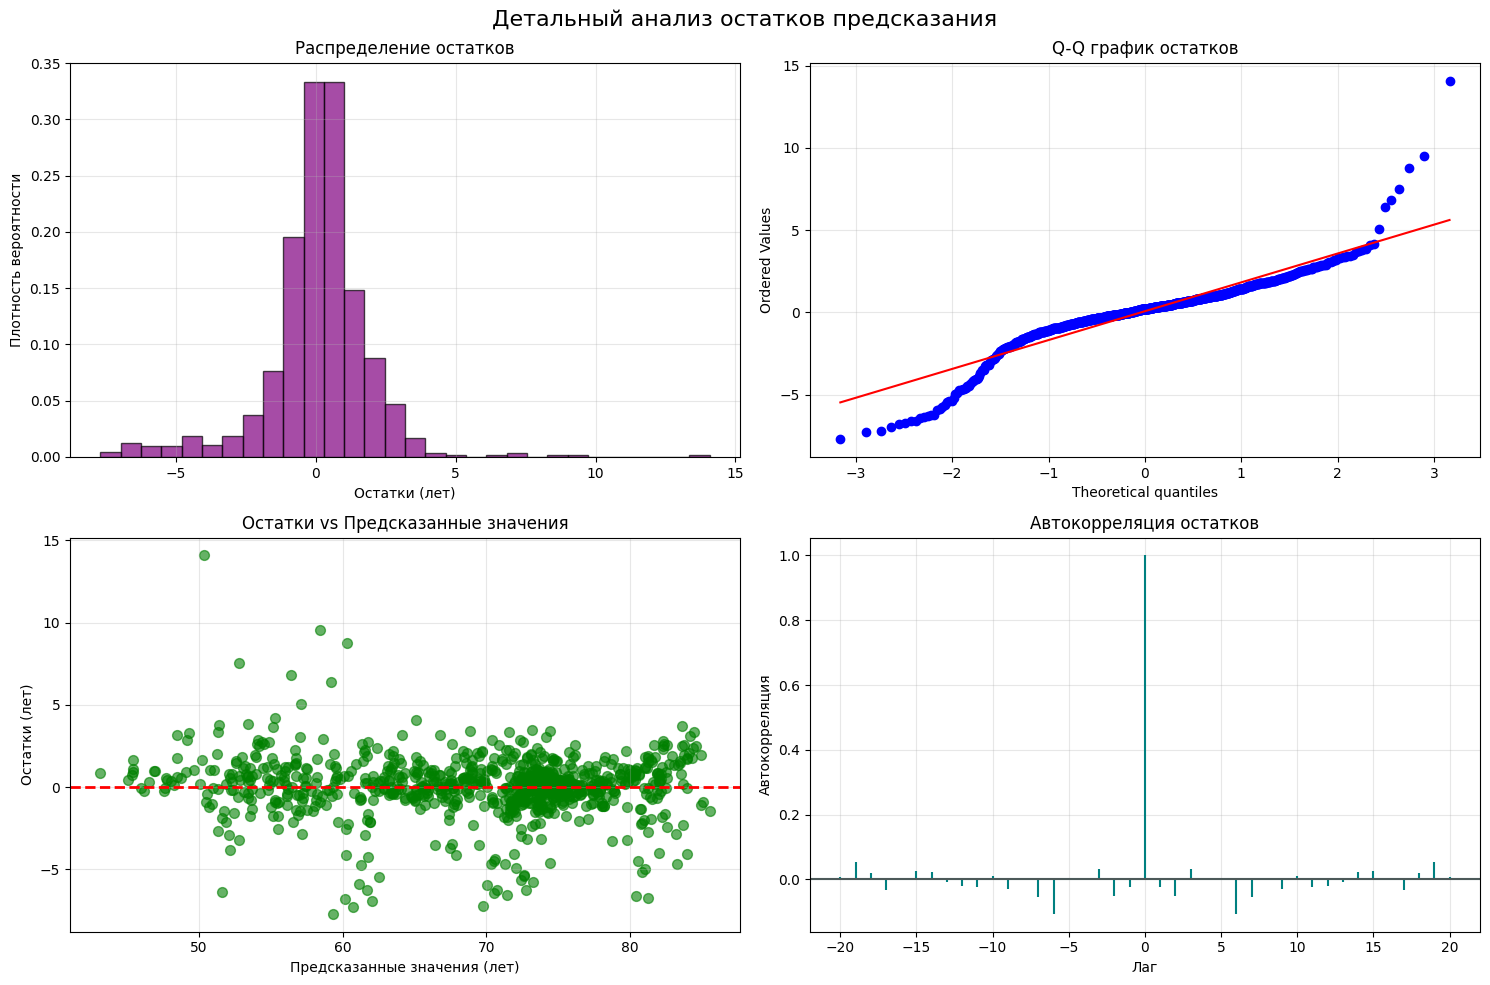


СРАВНЕНИЕ МОДЕЛЕЙ
           Модель   MSE  RMSE   MAE    R2
Gradient Boosting 3.493 1.869 1.224 0.963
    Random Forest 3.610 1.900 1.190 0.961

Gradient Boosting показывает лучшее качество


In [2]:
# @title GradientBoostingRegressor для предсказания продолжительности жизни
# gradient_boosting_regression

import os
import pandas as pd
import numpy as np
import sqlite3
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import joblib
import regression_visualization as rv


def load_processed_data(db_file='life_expectancy.db'):
    """Загрузка обработанных данных из БД."""
    try:
        conn = sqlite3.connect(db_file)
        df = pd.read_sql_query('SELECT * FROM life_expectancy_processed', conn)
        conn.close()

        target_col = 'Life_expectancy'
        if target_col not in df.columns:
            possible_targets = [col for col in df.columns
                              if 'life' in col.lower() or 'expectancy' in col.lower()]
            if possible_targets:
                target_col = possible_targets[0]
            else:
                print("Ошибка: Не найдена целевая переменная")
                return None, None, None

        # Проверяем и преобразуем нечисловые колонки
        for col in df.columns:
            if col != target_col and df[col].dtype == 'object':
                from sklearn.preprocessing import LabelEncoder
                encoder = LabelEncoder()
                df[col] = encoder.fit_transform(df[col].astype(str))

        X = df.drop(target_col, axis=1)
        y = df[target_col]

        return X, y, target_col

    except Exception as e:
        print(f"Ошибка при загрузке данных: {e}")
        return None, None, None


def calculate_regression_metrics(y_true, y_pred, dataset_name):
    """Вычисление метрик регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Метрики на {dataset_name} выборке:")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R2: {r2:.4f}")

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


def train_gradient_boosting(X, y, test_size=0.3, random_state=42, tune_hyperparams=False):
    """Обучение модели Gradient Boosting."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print(f"Обучающая выборка: {X_train.shape}")
    print(f"Тестовая выборка: {X_test.shape}")

    if tune_hyperparams:
        print("Подбор гиперпараметров с помощью GridSearchCV...")
        param_grid = {
            'n_estimators': [100, 200],
            'learning_rate': [0.05, 0.1, 0.15],
            'max_depth': [3, 4, 5],
            'min_samples_split': [2, 5],
            'min_samples_leaf': [1, 2]
        }

        gb_regressor = GradientBoostingRegressor(random_state=random_state)
        grid_search = GridSearchCV(
            gb_regressor, param_grid, cv=5, scoring='r2',
            n_jobs=-1, verbose=1
        )
        grid_search.fit(X_train, y_train)

        gb_regressor = grid_search.best_estimator_
        print(f"Лучшие параметры: {grid_search.best_params_}")
        print(f"Лучший R2: {grid_search.best_score_:.4f}")

    else:
        # Базовые параметры
        gb_regressor = GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            min_samples_split=5,
            min_samples_leaf=2,
            subsample=0.8,
            random_state=random_state
        )

    print("Обучение модели Gradient Boosting...")
    gb_regressor.fit(X_train, y_train)

    y_pred_train = gb_regressor.predict(X_train)
    y_pred_test = gb_regressor.predict(X_test)

    return {
        'model': gb_regressor,
        'X_train': X_train,
        'X_test': X_test,
        'y_train': y_train,
        'y_test': y_test,
        'y_pred_train': y_pred_train,
        'y_pred_test': y_pred_test
    }


def analyze_feature_importance(model, feature_names, top_n=15):
    """Анализ важности признаков."""
    feature_importance = pd.DataFrame({
        'feature': feature_names,
        'importance': model.feature_importances_
    }).sort_values('importance', ascending=False)

    print(f"Топ-{top_n} самых важных признаков:")
    print(feature_importance.head(top_n).to_string(index=False))

    return feature_importance


def compare_with_random_forest(gb_metrics, rf_metrics=None):
    """Сравнение метрик Gradient Boosting и Random Forest."""
    print("\nСРАВНЕНИЕ МОДЕЛЕЙ")
    print("=" * 50)

    comparison_data = []

    # Метрики Gradient Boosting
    comparison_data.append({
        'Модель': 'Gradient Boosting',
        'MSE': gb_metrics['MSE'],
        'RMSE': gb_metrics['RMSE'],
        'MAE': gb_metrics['MAE'],
        'R2': gb_metrics['R2']
    })

    # Метрики Random Forest (если предоставлены)
    if rf_metrics:
        comparison_data.append({
            'Модель': 'Random Forest',
            'MSE': rf_metrics['MSE'],
            'RMSE': rf_metrics['RMSE'],
            'MAE': rf_metrics['MAE'],
            'R2': rf_metrics['R2']
        })

    comparison_df = pd.DataFrame(comparison_data)
    print(comparison_df.to_string(index=False, float_format='%.3f'))

    # Анализ лучшей модели
    if rf_metrics:
        if gb_metrics['R2'] > rf_metrics['R2']:
            print("\nGradient Boosting показывает лучшее качество")
        elif gb_metrics['R2'] < rf_metrics['R2']:
            print("\nRandom Forest показывает лучшее качество")
        else:
            print("\nМодели показывают схожее качество")


def safe_visualization(y_test, y_pred_test, model, feature_names):
    """Безопасное выполнение визуализаций с обработкой ошибок."""
    try:
        print("\nВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ")
        print("=" * 50)

        # Основная визуализация
        rv.plot_regression_results(
            y_test,
            y_pred_test,
            model=model,
            feature_names=feature_names
        )

        # Дополнительные визуализации с обработкой ошибок индексов
        print("\nСРАВНЕНИЕ ПЕРВЫХ 50 ЗНАЧЕНИЙ:")
        try:
            rv.plot_predictions(y_test, y_pred_test, num_points=50)
        except Exception as e:
            print(f"Ошибка в plot_predictions: {e}")
            print("Пропускаем эту визуализацию")

        # try:
        #     rv.plot_prediction_comparison(y_test, y_pred_test)
        # except Exception as e:
        #     print(f"Ошибка в plot_prediction_comparison: {e}")
        #     print("Пропускаем эту визуализацию")

        try:
            rv.plot_residual_analysis(y_test, y_pred_test)
        except Exception as e:
            print(f"Ошибка в plot_residual_analysis: {e}")
            print("Пропускаем эту визуализацию")

    except Exception as e:
        print(f"Ошибка при визуализации: {e}")


def reset_indexes_for_visualization(y_test, y_pred_test):
    """Сбрасывает индексы для корректной визуализации."""
    if hasattr(y_test, 'reset_index'):
        y_test_reset = y_test.reset_index(drop=True)
    else:
        y_test_reset = pd.Series(y_test).reset_index(drop=True)

    if hasattr(y_pred_test, 'reset_index'):
        y_pred_test_reset = y_pred_test.reset_index(drop=True)
    else:
        y_pred_test_reset = pd.Series(y_pred_test).reset_index(drop=True)

    return y_test_reset, y_pred_test_reset


def main(tune_hyperparams=False, rf_metrics=None):
    """Основная функция программы."""
    print("ПРЕДСКАЗАНИЕ ПРОДОЛЖИТЕЛЬНОСТИ ЖИЗНИ С ПОМОЩЬЮ GRADIENT BOOSTING")
    print("=" * 70)

    try:
        X, y, target_col = load_processed_data()

        if X is None or y is None:
            print("Не удалось загрузить данные")
            return

        print(f"Целевая переменная: {target_col}")
        print(f"Размерность данных: {X.shape}")

        results = train_gradient_boosting(X, y, tune_hyperparams=tune_hyperparams)

        print("\nМЕТРИКИ КАЧЕСТВА МОДЕЛИ")
        print("=" * 50)

        train_metrics = calculate_regression_metrics(
            results['y_train'], results['y_pred_train'], "обучающей"
        )
        test_metrics = calculate_regression_metrics(
            results['y_test'], results['y_pred_test'], "тестовой"
        )

        feature_importance = analyze_feature_importance(
            results['model'], X.columns.tolist()
        )

        # Исправление индексов для визуализации
        y_test_fixed, y_pred_fixed = reset_indexes_for_visualization(
            results['y_test'], results['y_pred_test']
        )

        # Безопасная визуализация
        safe_visualization(
            y_test_fixed,
            y_pred_fixed,
            results['model'],
            X.columns.tolist()
        )

        # Сравнение с Random Forest
        compare_with_random_forest(test_metrics, rf_metrics)

        # joblib.dump(results['model'], 'gradient_boosting_model.pkl')
        # print("Модель сохранена в gradient_boosting_model.pkl")

        return {
            'model': results['model'],
            'X_train': results['X_train'],
            'X_test': results['X_test'],
            'y_train': results['y_train'],
            'y_test': results['y_test'],
            'y_pred_train': results['y_pred_train'],
            'y_pred_test': results['y_pred_test'],
            'train_metrics': train_metrics,
            'test_metrics': test_metrics,
            'feature_importance': feature_importance
        }

    except Exception as e:
        print(f"Критическая ошибка: {e}")
        import traceback
        traceback.print_exc()
        return None


if __name__ == "__main__":
    # Для сравнения с Random Forest передайте метрики RF
    rf_metrics_example = {
        'MSE': 3.61,
        'RMSE': 1.90,
        'MAE': 1.19,
        'R2': 0.9613
    }

    # Запуск без подбора гиперпараметров (быстрее)
    results = main(tune_hyperparams=False, rf_metrics=rf_metrics_example)

    # Запуск с подбором гиперпараметров
    # results = main(tune_hyperparams=True, rf_metrics=rf_metrics_example)

ПРЕДСКАЗАНИЕ ПРОДОЛЖИТЕЛЬНОСТИ ЖИЗНИ С ПОМОЩЬЮ АНСАМБЛЕЙ
Целевая переменная: Life_expectancy
Размерность данных: (2928, 21)
Обучающая выборка: (2049, 21)
Тестовая выборка: (879, 21)

Обучение Voting Regressor...
Метрики на обучающей выборке:
  MSE: 1.71
  RMSE: 1.31
  MAE: 0.92
  R2: 0.9809
Метрики на тестовой выборке:
  MSE: 4.30
  RMSE: 2.07
  MAE: 1.36
  R2: 0.9540

Обучение Stacking Regressor...
Метрики на обучающей выборке:
  MSE: 0.53
  RMSE: 0.73
  MAE: 0.50
  R2: 0.9940
Метрики на тестовой выборке:
  MSE: 3.25
  RMSE: 1.80
  MAE: 1.14
  R2: 0.9652

ОБУЧЕНИЕ БАЗОВЫХ МОДЕЛЕЙ

Обучение rf...
Метрики на тестовой выборке:
  MSE: 3.61
  RMSE: 1.90
  MAE: 1.19
  R2: 0.9613

Обучение gb...
Метрики на тестовой выборке:
  MSE: 3.49
  RMSE: 1.87
  MAE: 1.22
  R2: 0.9626

Обучение ridge...
Метрики на тестовой выборке:
  MSE: 16.94
  RMSE: 4.12
  MAE: 3.03
  R2: 0.8186

Обучение svr...
Метрики на тестовой выборке:
  MSE: 13.90
  RMSE: 3.73
  MAE: 2.55
  R2: 0.8512

СРАВНЕНИЕ РЕЗУЛЬТАТОВ МОД

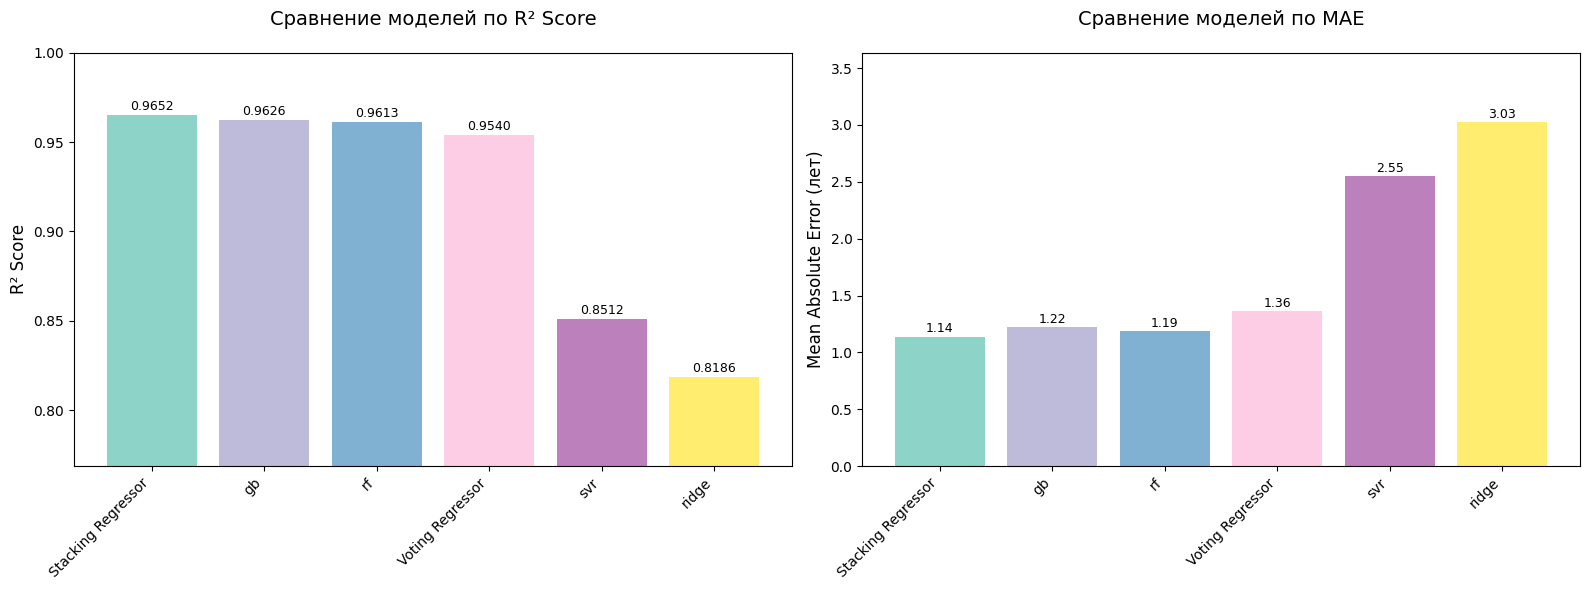

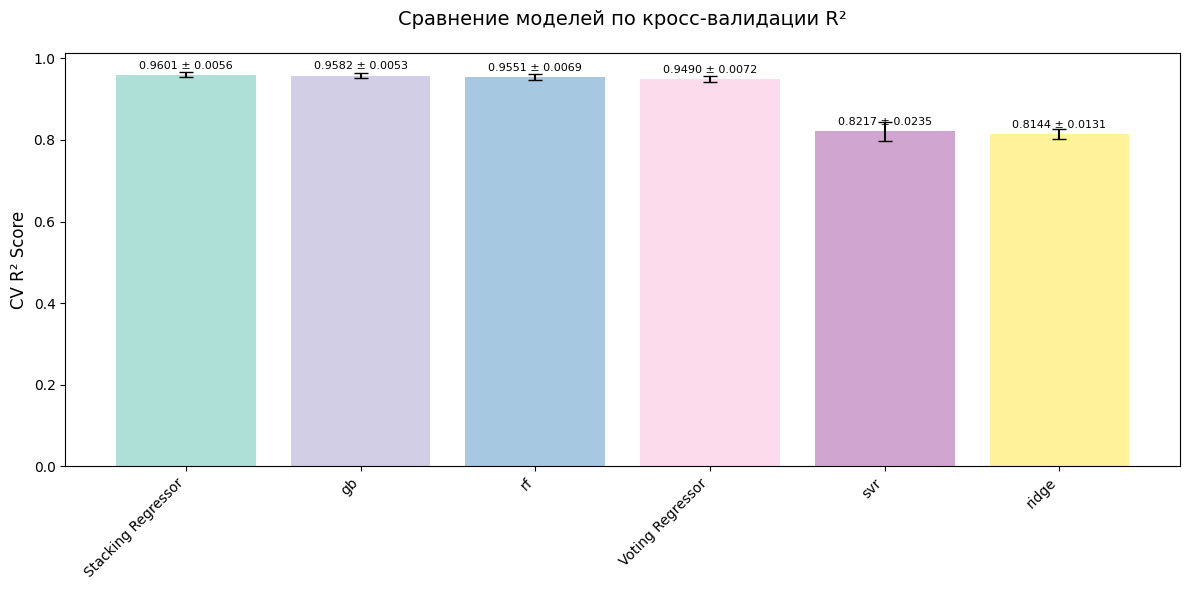


ЛУЧШАЯ МОДЕЛЬ: Stacking Regressor
   R²: 0.9652
   MAE: 1.14 лет
   CV R²: 0.9601 ± 0.0056

АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ
Усредненная важность признаков (Voting Regressor):
                        feature  importance
                       HIV_AIDS    0.565698
Income_composition_of_resources    0.178558
                Adult_Mortality    0.137080
              under_five_deaths    0.020432
                            BMI    0.014814
             thinness_5_9_years    0.012999
                      Schooling    0.011663
                        Alcohol    0.008199
                           Year    0.007645
                        Country    0.005343
            thinness_1_19_years    0.005285
                        Measles    0.004472
                     Diphtheria    0.004436
                          Polio    0.004083
              Total_expenditure    0.003875

ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ЛУЧШЕЙ МОДЕЛИ


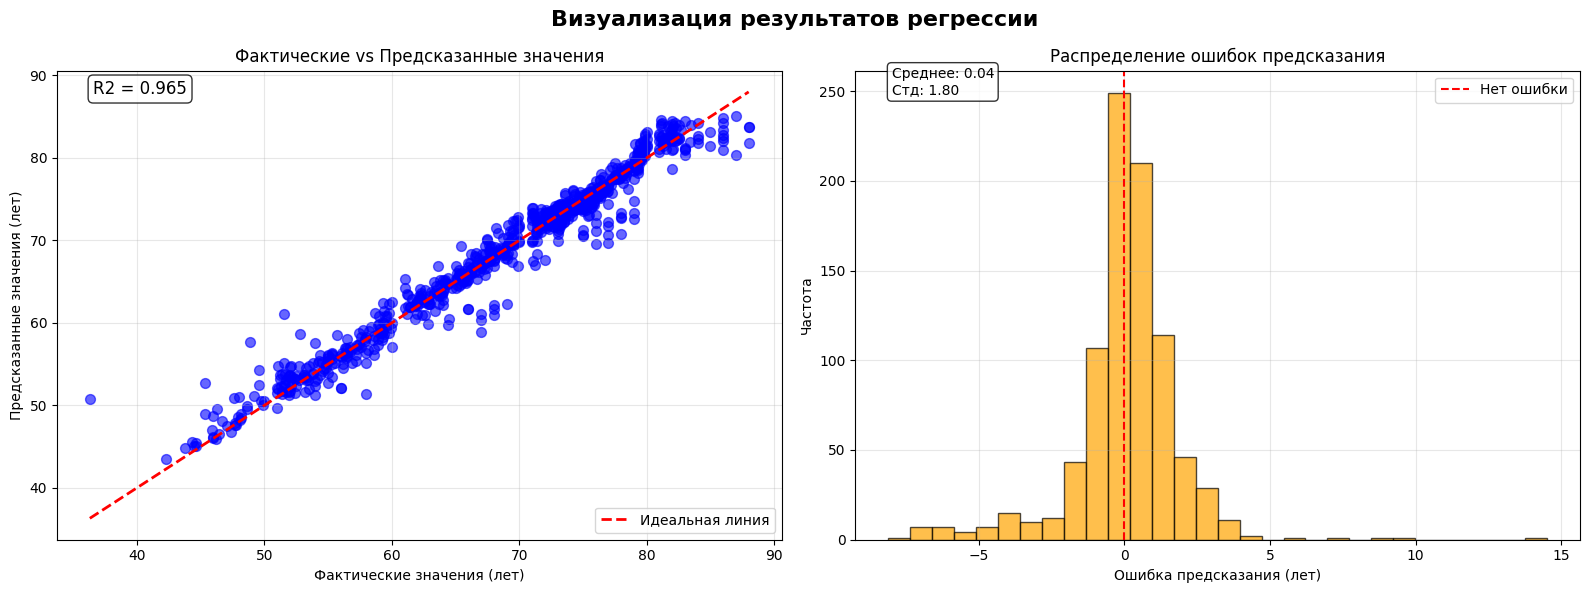

МЕТРИКИ РЕГРЕССИИ:
Mean Squared Error (MSE): 3.25
Root Mean Squared Error (RMSE): 1.80
Mean Absolute Error (MAE): 1.14
R2 Score: 0.9652

СТАТИСТИКА ОШИБОК:
Средняя ошибка: 0.04 лет
Стандартное отклонение ошибок: 1.80 лет
Медианная ошибка: 0.11 лет
Максимальная ошибка: 14.51 лет
Минимальная ошибка: -8.11 лет

ДОПОЛНИТЕЛЬНЫЕ ВИЗУАЛИЗАЦИИ ДЛЯ Stacking Regressor:


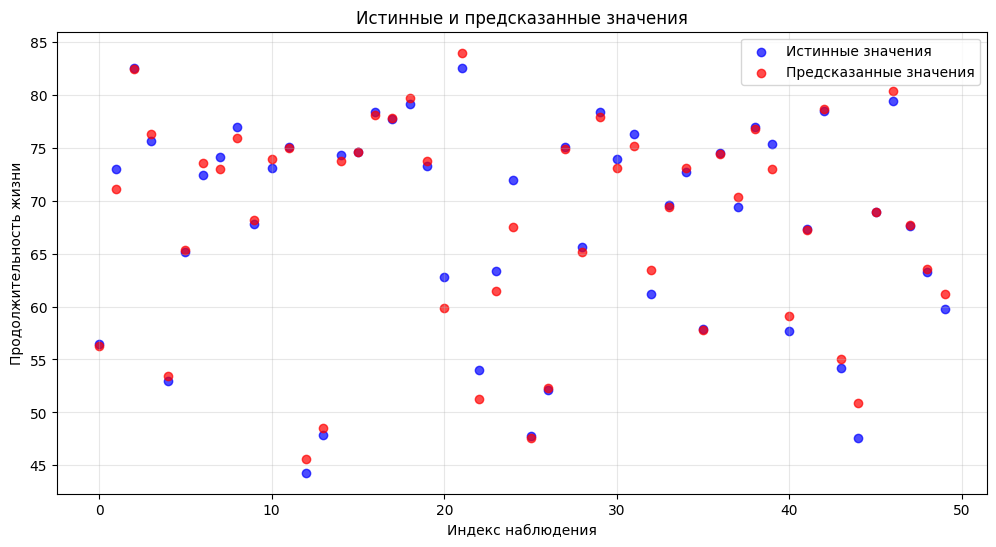

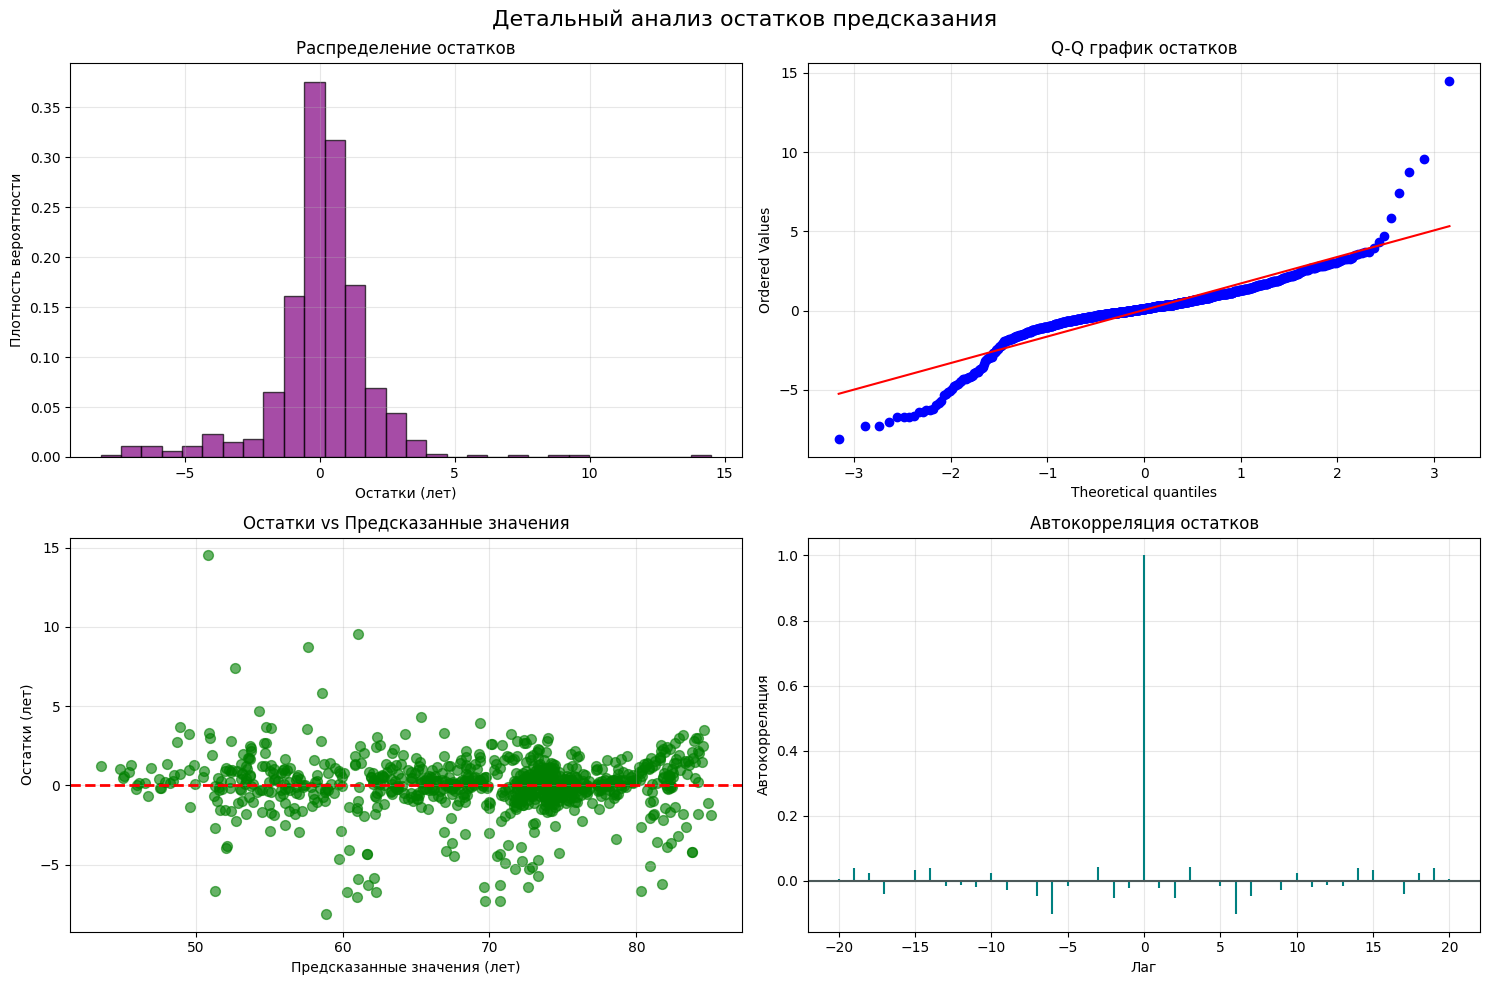

Лучшая модель сохранена: best_ensemble_model_Stacking_Regressor.pkl


In [3]:
# @title Ансамбль регрессоров для предсказания продолжительности жизни
# ensemble_regression

import os
import pandas as pd
import numpy as np
import sqlite3
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler
import joblib
import regression_visualization as rv


def load_processed_data(db_file='life_expectancy.db'):
    """Загрузка обработанных данных из БД."""
    try:
        conn = sqlite3.connect(db_file)
        df = pd.read_sql_query('SELECT * FROM life_expectancy_processed', conn)
        conn.close()

        target_col = 'Life_expectancy'
        if target_col not in df.columns:
            possible_targets = [col for col in df.columns
                              if 'life' in col.lower() or 'expectancy' in col.lower()]
            if possible_targets:
                target_col = possible_targets[0]
            else:
                print("Ошибка: Не найдена целевая переменная")
                return None, None, None

        # Преобразование категориальных признаков
        for col in df.columns:
            if col != target_col and df[col].dtype == 'object':
                from sklearn.preprocessing import LabelEncoder
                encoder = LabelEncoder()
                df[col] = encoder.fit_transform(df[col].astype(str))

        X = df.drop(target_col, axis=1)
        y = df[target_col]

        return X, y, target_col

    except Exception as e:
        print(f"Ошибка при загрузке данных: {e}")
        return None, None, None


def calculate_regression_metrics(y_true, y_pred, dataset_name):
    """Вычисление метрик регрессии."""
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"Метрики на {dataset_name} выборке:")
    print(f"  MSE: {mse:.2f}")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE: {mae:.2f}")
    print(f"  R2: {r2:.4f}")

    return {
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R2': r2
    }


def create_ensemble_models():
    """Создание ансамблевых моделей."""

    # Базовые модели
    base_models = [
        ('rf', RandomForestRegressor(
            n_estimators=100,
            max_depth=15,
            random_state=42,
            n_jobs=-1
        )),
        ('gb', GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.1,
            max_depth=4,
            min_samples_split=5,
            min_samples_leaf=2,
            subsample=0.8,
            random_state=42
        )),
        ('ridge', Ridge(alpha=1.0)),
        ('svr', SVR(kernel='rbf', C=1.0, gamma='scale'))
    ]

    # Voting Regressor (усреднение предсказаний)
    voting_regressor = VotingRegressor(
        estimators=base_models,
        weights=[3, 3, 1, 1]  # Веса для моделей
    )

    # Stacking Regressor (мета-модель)
    stacking_regressor = StackingRegressor(
        estimators=base_models,
        final_estimator=LinearRegression(),
        cv=5,
        passthrough=False
    )

    return {
        'Voting Regressor': voting_regressor,
        'Stacking Regressor': stacking_regressor,
        'Base Models': dict(base_models)
    }


def train_ensemble_models(X, y, test_size=0.3, random_state=42):
    """Обучение ансамблевых моделей."""
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_size, random_state=random_state
    )

    print(f"Обучающая выборка: {X_train.shape}")
    print(f"Тестовая выборка: {X_test.shape}")

    # Создаем ансамблевые модели
    ensemble_models = create_ensemble_models()
    results = {}

    # Обучаем каждую модель
    for model_name, model in ensemble_models.items():
        if model_name == 'Base Models':
            continue

        print(f"\nОбучение {model_name}...")
        model.fit(X_train, y_train)

        # Предсказания
        y_pred_train = model.predict(X_train)
        y_pred_test = model.predict(X_test)

        # Метрики
        train_metrics = calculate_regression_metrics(y_train, y_pred_train, "обучающей")
        test_metrics = calculate_regression_metrics(y_test, y_pred_test, "тестовой")

        # Кросс-валидация
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

        results[model_name] = {
            'model': model,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test,
            'y_pred_train': y_pred_train,
            'y_pred_test': y_pred_test,
            'train_metrics': train_metrics,
            'test_metrics': test_metrics,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std()
        }

    # Обучаем базовые модели для сравнения
    print("\n" + "="*50)
    print("ОБУЧЕНИЕ БАЗОВЫХ МОДЕЛЕЙ")
    print("="*50)

    for model_name, model in ensemble_models['Base Models'].items():
        print(f"\nОбучение {model_name}...")
        model.fit(X_train, y_train)

        y_pred_test = model.predict(X_test)
        test_metrics = calculate_regression_metrics(y_test, y_pred_test, "тестовой")

        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2')

        results[model_name] = {
            'model': model,
            'test_metrics': test_metrics,
            'cv_mean': cv_scores.mean(),
            'cv_std': cv_scores.std()
        }

    return results


def compare_ensemble_results(results):
    """Сравнение результатов ансамблевых моделей."""
    print("\n" + "="*60)
    print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ МОДЕЛЕЙ")
    print("="*60)

    comparison_data = []

    for model_name, result in results.items():
        if 'test_metrics' in result:
            metrics = result['test_metrics']
            comparison_data.append({
                'Модель': model_name,
                'R2': metrics['R2'],
                'MAE': metrics['MAE'],
                'RMSE': metrics['RMSE'],
                'CV R2 Mean': result.get('cv_mean', 0),
                'CV R2 Std': result.get('cv_std', 0)
            })

    comparison_df = pd.DataFrame(comparison_data).sort_values('R2', ascending=False)
    print(comparison_df.to_string(index=False, float_format='%.4f'))

    # Визуализация сравнения
    plot_ensemble_comparison(comparison_df)

    return comparison_df


def plot_ensemble_comparison(comparison_df):
    """Визуализация сравнения ансамблевых моделей."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # График R2
    models = comparison_df['Модель'].values
    r2_scores = comparison_df['R2'].values

    # Создаем цвета для всех моделей
    colors = plt.cm.Set3(np.linspace(0, 1, len(models)))

    bars1 = ax1.bar(range(len(models)), r2_scores, color=colors)
    ax1.set_title('Сравнение моделей по R² Score', fontsize=14, pad=20)
    ax1.set_ylabel('R² Score', fontsize=12)
    ax1.set_ylim(max(0, min(r2_scores) - 0.05), min(1.0, max(r2_scores) + 0.05))

    # Устанавливаем подписи по центру столбцов
    ax1.set_xticks(range(len(models)))
    ax1.set_xticklabels(models, rotation=45, ha='right', fontsize=10)

    # Добавляем значения на столбцы
    for bar, value in zip(bars1, r2_scores):
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height + 0.001,
                f'{value:.4f}', ha='center', va='bottom', fontsize=9)

    # График MAE
    mae_scores = comparison_df['MAE'].values

    bars2 = ax2.bar(range(len(models)), mae_scores, color=colors)
    ax2.set_title('Сравнение моделей по MAE', fontsize=14, pad=20)
    ax2.set_ylabel('Mean Absolute Error (лет)', fontsize=12)
    ax2.set_ylim(0, max(mae_scores) * 1.2)

    # Устанавливаем подписи по центру столбцов
    ax2.set_xticks(range(len(models)))
    ax2.set_xticklabels(models, rotation=45, ha='right', fontsize=10)

    # Добавляем значения на столбцы
    for bar, value in zip(bars2, mae_scores):
        height = bar.get_height()
        ax2.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                f'{value:.2f}', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    # Дополнительный график для кросс-валидации
    if 'CV R2 Mean' in comparison_df.columns:
        fig, ax3 = plt.subplots(figsize=(12, 6))

        cv_means = comparison_df['CV R2 Mean'].values
        cv_stds = comparison_df['CV R2 Std'].values

        # Заменяем нулевые значения на NaN для пропуска в визуализации
        cv_means_to_plot = np.where(cv_means == 0, np.nan, cv_means)
        cv_stds_to_plot = np.where(cv_stds == 0, np.nan, cv_stds)

        bars3 = ax3.bar(range(len(models)), cv_means_to_plot,
                       yerr=cv_stds_to_plot, capsize=5, color=colors, alpha=0.7)

        ax3.set_title('Сравнение моделей по кросс-валидации R²', fontsize=14, pad=20)
        ax3.set_ylabel('CV R² Score', fontsize=12)
        ax3.set_xticks(range(len(models)))
        ax3.set_xticklabels(models, rotation=45, ha='right', fontsize=10)

        # Добавляем значения только для тех моделей, где есть данные
        for i, (bar, mean_val, std_val) in enumerate(zip(bars3, cv_means, cv_stds)):
            if mean_val > 0:  # Показываем только если есть данные
                height = bar.get_height()
                ax3.text(bar.get_x() + bar.get_width()/2, height + 0.01,
                        f'{mean_val:.4f} ± {std_val:.4f}', ha='center', va='bottom', fontsize=8)
            else:
                # Показываем "N/A" для моделей без данных кросс-валидации
                ax3.text(bar.get_x() + bar.get_width()/2, 0.02,
                        'N/A', ha='center', va='bottom', fontsize=8)

        plt.tight_layout()
        plt.show()

    # Лучшая модель
    best_model = comparison_df.iloc[0]
    print(f"\nЛУЧШАЯ МОДЕЛЬ: {best_model['Модель']}")
    print(f"   R²: {best_model['R2']:.4f}")
    print(f"   MAE: {best_model['MAE']:.2f} лет")
    print(f"   CV R²: {best_model['CV R2 Mean']:.4f} ± {best_model['CV R2 Std']:.4f}")


def analyze_feature_importance_ensemble(results, feature_names, top_n=15):
    """Анализ важности признаков для ансамблевых моделей."""
    print("\n" + "="*50)
    print("АНАЛИЗ ВАЖНОСТИ ПРИЗНАКОВ")
    print("="*50)

    # Для Voting Regressor (усредненная важность)
    if 'Voting Regressor' in results:
        voting_model = results['Voting Regressor']['model']
        feature_importance_avg = np.zeros(len(feature_names))
        count_models_with_importance = 0

        for name, model in voting_model.estimators:
            if hasattr(model, 'feature_importances_'):
                feature_importance_avg += model.feature_importances_
                count_models_with_importance += 1

        if count_models_with_importance > 0:
            feature_importance_avg /= count_models_with_importance

            feature_importance_df = pd.DataFrame({
                'feature': feature_names,
                'importance': feature_importance_avg
            }).sort_values('importance', ascending=False)

            print("Усредненная важность признаков (Voting Regressor):")
            print(feature_importance_df.head(top_n).to_string(index=False))

            return feature_importance_df
        else:
            print("Ни одна из моделей в VotingRegressor не поддерживает feature_importances_")
            return None

    return None


def main():
    """Основная функция программы."""
    print("ПРЕДСКАЗАНИЕ ПРОДОЛЖИТЕЛЬНОСТИ ЖИЗНИ С ПОМОЩЬЮ АНСАМБЛЕЙ")
    print("=" * 70)

    try:
        X, y, target_col = load_processed_data()

        if X is None or y is None:
            print("Не удалось загрузить данные")
            return

        print(f"Целевая переменная: {target_col}")
        print(f"Размерность данных: {X.shape}")

        # Обучение ансамблевых моделей
        results = train_ensemble_models(X, y)

        # Сравнение результатов
        comparison_df = compare_ensemble_results(results)

        # Анализ важности признаков
        feature_importance_df = analyze_feature_importance_ensemble(
            results, X.columns.tolist()
        )

        # Визуализация результатов лучшей модели
        print("\n" + "="*50)
        print("ВИЗУАЛИЗАЦИЯ РЕЗУЛЬТАТОВ ЛУЧШЕЙ МОДЕЛИ")
        print("="*50)

        best_model_name = comparison_df.iloc[0]['Модель']
        best_result = results[best_model_name]

        rv.plot_regression_results(
            best_result['y_test'],
            best_result['y_pred_test'],
            model=best_result['model'],
            feature_names=X.columns.tolist()
        )

        # Дополнительные визуализации
        print(f"\nДОПОЛНИТЕЛЬНЫЕ ВИЗУАЛИЗАЦИИ ДЛЯ {best_model_name}:")
        rv.plot_predictions(best_result['y_test'], best_result['y_pred_test'], num_points=50)
        rv.plot_residual_analysis(best_result['y_test'], best_result['y_pred_test'])

        # Сохранение лучшей модели
        joblib.dump(best_result['model'], f'best_ensemble_model_{best_model_name.replace(" ", "_")}.pkl')
        print(f"Лучшая модель сохранена: best_ensemble_model_{best_model_name.replace(' ', '_')}.pkl")

        return {
            'results': results,
            'comparison_df': comparison_df,
            'best_model': best_model_name,
            'best_result': best_result,
            'feature_importance': feature_importance_df
        }

    except Exception as e:
        print(f"Критическая ошибка: {e}")
        import traceback
        traceback.print_exc()
        return None


if __name__ == "__main__":
    results = main()